# QRC Demo — Timeseries Prediction (Python)

This notebook demonstrates **Quantum Reservoir Computing for timeseries prediction** in Python. We use the *Mackey-Glass* delay-differential equation as our benchmark (a classic chaotic timeseries, analogous to the Santa Fe laser dataset used in the original Julia notebook).

The key difference from the MNIST demo is the **encoding strategy**: instead of mapping image features to local per-atom detunings, we use **global detuning encoding** — the timeseries values are encoded as a time-varying global detuning applied uniformly to all atoms.

**Pipeline:**
1. Generate the Mackey-Glass chaotic timeseries.
2. Create sliding windows and encode them via global pulse detuning.
3. Evolve the classical spin reservoir under the time-varying detuning.
4. Train a linear readout (Ridge regression) on the reservoir states.
5. Predict future values and evaluate with NRMSE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


## Generating the Mackey-Glass Timeseries

The Mackey-Glass equation is a delay-differential equation producing rich chaotic dynamics:

$$\frac{dx}{dt} = \frac{\beta x(t - \tau)}{1 + x(t-\tau)^n} - \gamma x(t)$$

with $\beta=0.2$, $\gamma=0.1$, $n=10$, $\tau=17$.

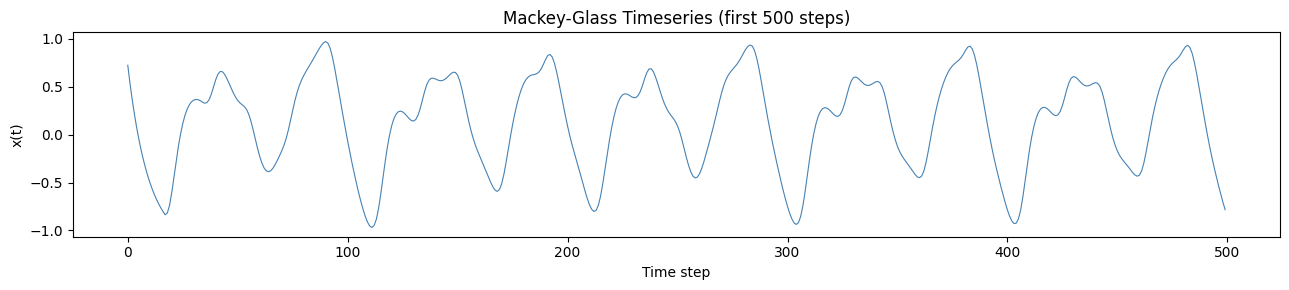

Timeseries length: 3000, range: [-1.00, 1.00]


In [2]:
def mackey_glass(n_steps=3000, tau=17, beta=0.2, gamma=0.1, n=10, dt=1.0, x0=1.2):
    history = [x0] * (tau + 1)
    xs = [x0]
    x = x0
    for _ in range(n_steps - 1):
        x_tau = history[-tau]
        dx = beta * x_tau / (1 + x_tau**n) - gamma * x
        x = x + dx * dt
        history.append(x)
        xs.append(x)
    return np.array(xs)

mg = mackey_glass(n_steps=3000)
# Normalize to [-1, 1]
mg = (mg - mg.min()) / (mg.max() - mg.min()) * 2 - 1

plt.figure(figsize=(13, 3))
plt.plot(mg[:500], color='steelblue', linewidth=0.8)
plt.title("Mackey-Glass Timeseries (first 500 steps)")
plt.xlabel("Time step"); plt.ylabel("x(t)")
plt.tight_layout(); plt.show()
print(f"Timeseries length: {len(mg)}, range: [{mg.min():.2f}, {mg.max():.2f}]")


## Sliding Window Preprocessing

We use a sliding window of length `W` as input and predict `HORIZON` steps ahead.

In [3]:
WINDOW   = 20    # input window length
HORIZON  = 1     # predict this many steps ahead
DELTA_MAX = 6.0  # detuning range (rad/µs) — maps [-1,1] → [-6,6]

def make_windows(series, window, horizon):
    X, y = [], []
    for i in range(len(series) - window - horizon + 1):
        X.append(series[i:i+window])
        y.append(series[i+window+horizon-1])
    return np.array(X), np.array(y)

# Split: first 2000 for train, next 500 for test
TRAIN_END = 2000
X_wins, y_vals = make_windows(mg, WINDOW, HORIZON)
X_tr_wins, y_tr = X_wins[:TRAIN_END], y_vals[:TRAIN_END]
X_te_wins, y_te = X_wins[TRAIN_END:TRAIN_END+500], y_vals[TRAIN_END:TRAIN_END+500]

# Scale windows to detuning range
X_tr_delta = X_tr_wins * DELTA_MAX
X_te_delta = X_te_wins * DELTA_MAX
print(f"Train windows: {X_tr_delta.shape}, Test windows: {X_te_delta.shape}")


Train windows: (2000, 20), Test windows: (500, 20)


## Global Detuning Encoding with Classical Spin Reservoir

In the **global detuning** scheme, each time step of the input window sets the detuning for all atoms simultaneously. The reservoir integrates these inputs via its coupled spin dynamics, creating a rich nonlinear representation.

$$\Delta_i(t_{step}) = \text{input}[t_{step}] \quad \forall i$$

The Rydberg-like classical spin ODE is solved piecewise, one segment per window element.

In [4]:
# ── CRC ODE with piecewise-constant global detuning ─────────────────────────
def generate_Vmat(locs, C6):
    n = len(locs)
    Vmat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                d = np.linalg.norm(locs[i] - locs[j])
                Vmat[i, j] = C6 / d**6
    VDel = Vmat.sum(axis=1)
    return Vmat, VDel

def deriv(t, u, nsites, Delta_uniform, Omega, Vmat, VDel):
    du = np.zeros_like(u)
    sz = u[2::3]
    Bv = Vmat @ sz
    for i in range(nsites):
        Bx = Omega / 2
        Bz = (-Delta_uniform + Bv[i]/2 + VDel[i]/2) / 2
        sx, sy, sz_i = u[3*i], u[3*i+1], u[3*i+2]
        du[3*i]   = Bz*sy
        du[3*i+1] = Bx*sz_i - Bz*sx
        du[3*i+2] = -Bx*sy
    return du

def apply_global_reservoir(window_deltas, nsites, locs, Omega, C6, seg_time=0.5):
    """
    Encode one window of detuning values as global piecewise-constant pulses.
    Returns flattened z-components of all spins at end of each segment.
    """
    Vmat, VDel = generate_Vmat(locs, C6)
    u = np.zeros(3 * nsites)
    u[2::3] = -1.0   # all spins pointing down
    
    readouts = []
    for delta_val in window_deltas:
        sol = solve_ivp(deriv, [0, seg_time], u,
                        args=(nsites, delta_val, Omega, Vmat, VDel),
                        method='RK45', rtol=1e-4, atol=1e-6,
                        t_eval=[seg_time])
        u = sol.y[:, -1]
        readouts.append(u[2::3].copy())  # z-components only
    return np.concatenate(readouts)      # shape: window * nsites

print("Reservoir functions defined.")


Reservoir functions defined.


## Configuring the Reservoir

| Parameter | Symbol | Default | Effect |
|-----------|--------|---------|--------|
| Atom count | $N$ | 8 | Reservoir size |
| Atom spacing | $d$ | 10 µm | Interaction strength (via $V_{ij}$) |
| C6 | $C_6$ | 862690·2π | Base interaction coefficient |
| Rabi frequency | $\Omega$ | 2π rad/µs | Drive strength |
| Segment time | $t_{seg}$ | 0.5 µs | Time each input value drives the reservoir |

**Try changing `ATOM_SPACING`, `C6_FACTOR`, or `SEG_TIME` to improve prediction accuracy!**

In [5]:
NSITES       = 8
ATOM_SPACING = 10.0             # µm ← change me!
C6_FACTOR    = 1.0              # scale C6 ← change me!
C6           = 862690 * 2*np.pi * C6_FACTOR
OMEGA        = 2 * np.pi
SEG_TIME     = 0.5              # µs per window element ← change me!

locs = np.array([[i * ATOM_SPACING, 0.0] for i in range(NSITES)])
print(f"Reservoir: {NSITES} atoms | spacing={ATOM_SPACING} µm | C6_factor={C6_FACTOR} | seg_time={SEG_TIME} µs")
print(f"Embedding dim per sample: {WINDOW * NSITES}")


Reservoir: 8 atoms | spacing=10.0 µm | C6_factor=1.0 | seg_time=0.5 µs
Embedding dim per sample: 160


In [6]:
print("Generating training embeddings...")
emb_tr = np.array([apply_global_reservoir(w, NSITES, locs, OMEGA, C6, SEG_TIME)
                   for w in tqdm(X_tr_delta)])
print("Generating test embeddings...")
emb_te = np.array([apply_global_reservoir(w, NSITES, locs, OMEGA, C6, SEG_TIME)
                   for w in tqdm(X_te_delta)])
print(f"Train: {emb_tr.shape}, Test: {emb_te.shape}")


Generating training embeddings...


  0%|          | 0/2000 [00:00<?, ?it/s]

Generating test embeddings...


  0%|          | 0/500 [00:00<?, ?it/s]

Train: (2000, 160), Test: (500, 160)


## Training the Readout (Ridge Regression)

In [7]:
def nrmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / (y_true.max() - y_true.min())

results = {}
for alpha in [1e-4, 1e-2, 1.0, 10.0]:
    ridge = Ridge(alpha=alpha).fit(emb_tr, y_tr)
    pred_tr = ridge.predict(emb_tr)
    pred_te = ridge.predict(emb_te)
    tr_nrmse = nrmse(y_tr, pred_tr)
    te_nrmse = nrmse(y_te, pred_te)
    results[alpha] = (tr_nrmse, te_nrmse, ridge, pred_te)
    print(f"α={alpha:.0e} | Train NRMSE={tr_nrmse:.4f} | Test NRMSE={te_nrmse:.4f}")

best_alpha = min(results, key=lambda a: results[a][1])
best_pred  = results[best_alpha][3]
best_ridge = results[best_alpha][2]
print(f"\nBest alpha={best_alpha} (Test NRMSE={results[best_alpha][1]:.4f})")


α=1e-04 | Train NRMSE=0.0077 | Test NRMSE=0.0072
α=1e-02 | Train NRMSE=0.0084 | Test NRMSE=0.0080
α=1e+00 | Train NRMSE=0.0106 | Test NRMSE=0.0099
α=1e+01 | Train NRMSE=0.0157 | Test NRMSE=0.0155

Best alpha=0.0001 (Test NRMSE=0.0072)


In [8]:
# Baseline: predict using last element of window (naive)
naive_pred = X_te_wins[:, -1]
naive_nrmse = nrmse(y_te, naive_pred)
print(f"Naive baseline (last-value) NRMSE: {naive_nrmse:.4f}")

# Baseline: linear model on raw windows
ridge_raw = Ridge(alpha=1.0).fit(X_tr_wins, y_tr)
raw_nrmse = nrmse(y_te, ridge_raw.predict(X_te_wins))
print(f"Linear regression on raw windows NRMSE: {raw_nrmse:.4f}")


Naive baseline (last-value) NRMSE: 0.0377
Linear regression on raw windows NRMSE: 0.0108


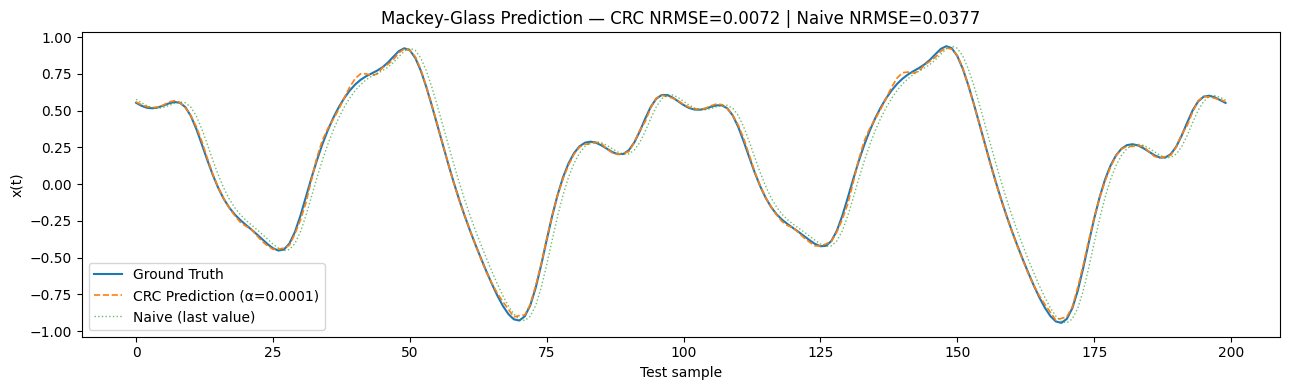

In [9]:
N_SHOW = 200
plt.figure(figsize=(13, 4))
plt.plot(y_te[:N_SHOW], label='Ground Truth', linewidth=1.5)
plt.plot(best_pred[:N_SHOW], '--', label=f'CRC Prediction (α={best_alpha})', linewidth=1.2)
plt.plot(naive_pred[:N_SHOW], ':', label='Naive (last value)', linewidth=1.0, alpha=0.7)
plt.xlabel("Test sample"); plt.ylabel("x(t)")
plt.title(f"Mackey-Glass Prediction — CRC NRMSE={results[best_alpha][1]:.4f} | Naive NRMSE={naive_nrmse:.4f}")
plt.legend(); plt.tight_layout(); plt.show()


## Parameter Sweep — Effect of Atom Spacing on Prediction

Atom spacing controls the $V_{ij}$ interaction strength. Larger spacing → weaker interactions.

spacing=  6.0 µm → NRMSE=0.1240
spacing=  8.0 µm → NRMSE=0.0804
spacing= 10.0 µm → NRMSE=0.0156
spacing= 14.0 µm → NRMSE=0.0649
spacing= 20.0 µm → NRMSE=0.1535


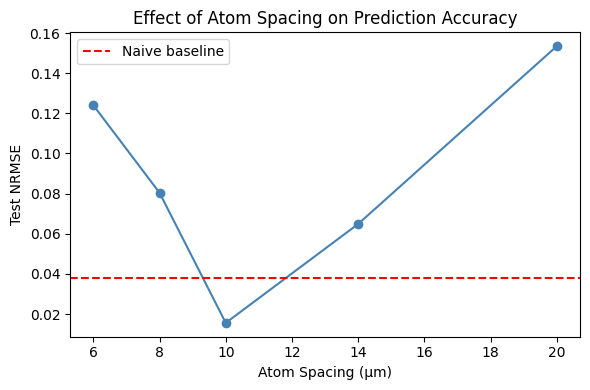

In [10]:
spacings = [6.0, 8.0, 10.0, 14.0, 20.0]
nrmse_per_spacing = []

for d_val in spacings:
    locs_s = np.array([[i*d_val, 0.0] for i in range(NSITES)])
    C6_s   = 862690 * 2*np.pi * C6_FACTOR
    
    emb_tr_s = np.array([apply_global_reservoir(w, NSITES, locs_s, OMEGA, C6_s, SEG_TIME)
                         for w in X_tr_delta[:300]])
    emb_te_s = np.array([apply_global_reservoir(w, NSITES, locs_s, OMEGA, C6_s, SEG_TIME)
                         for w in X_te_delta[:150]])
    
    ridge_s = Ridge(alpha=1.0).fit(emb_tr_s, y_tr[:300])
    nrmse_s = nrmse(y_te[:150], ridge_s.predict(emb_te_s))
    nrmse_per_spacing.append(nrmse_s)
    print(f"spacing={d_val:5.1f} µm → NRMSE={nrmse_s:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(spacings, nrmse_per_spacing, 'o-', color='steelblue')
plt.axhline(naive_nrmse, linestyle='--', color='red', label='Naive baseline')
plt.xlabel("Atom Spacing (µm)"); plt.ylabel("Test NRMSE")
plt.title("Effect of Atom Spacing on Prediction Accuracy")
plt.legend(); plt.tight_layout(); plt.show()


## Summary

The classical spin reservoir successfully predicts the Mackey-Glass chaotic timeseries using global detuning encoding. Key observations:
- The reservoir nonlinearity provides a significant improvement over the naive and linear baselines.
- Atom spacing (interaction strength) and segment time are the most impactful tunable parameters.
- For a quantum version: replace the classical ODE with full quantum state vector simulation (see `QRC Demo MNIST Python.ipynb`).
